<a href="https://colab.research.google.com/github/andrijanamilijancevic/PPPO-Detekcija-automobila-IT21-2022/blob/main/DrugaKontrolnaTacka.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Kontrolna tačka 2 – Analiza podataka, pretprocesiranje i baseline algoritmi**

Cilj ove faze je analiza dodeljenog dataset-a, sprovođenje osnovnog pretprocesiranja i izrada baseline modela koji će služiti kao polazna tačka za kasniju optimizaciju.


Prvo ćemo uplodovati fajl sa racunara.

In [ ]:
import zipfile
from google.colab import files
import os
# Upload fajla
uploaded = files.upload()

Saving Car_Object_Detection.zip to Car_Object_Detection.zip


- Kreirali smo folder u Colab okruženju pomoću funkcije os.makedirs.
Ova komanda osigurava da folder postoji, a ako već postoji, ne dolazi do greške. Sledeći korak je bio raspakovanje ZIP fajla, ako fajl nije validan ispisuju se poruke o greški. I na kraju smo proverili sadržaj pomoću os.listdir funkcije.
U našem slučaju, rezultat je pokazao da je fajl Car_Object_Detection.zip uspešno raspakovan i da se u folderu nalazi podfolder data.



In [ ]:
destination_folder = '/content/dataset'
os.makedirs(destination_folder, exist_ok=True)

# Raspakivanje ZIP fajla
for fn in uploaded.keys():
    try:
        with zipfile.ZipFile(fn, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)
        print(f'Uspesno raspakovano: {fn}')
    except zipfile.BadZipFile:
        print(f'Greska - "{fn}"')
    except Exception as e:
        print(f'Došlo je do greske"{fn}": {e}')

# Provera sadrzaja foldera
print("Sadrzaj foldera:", os.listdir(destination_folder))


Uspesno raspakovano: Car_Object_Detection.zip
Sadrzaj foldera: ['data']


**Karakteristike dodeljenog skupa podataka**

Cilj ovog dela je bio da se utvrdi broj klasa, njihova imena i broj uzoraka po svakoj klasi. Time se dobija osnovna statistika o dataset-u, koja je neophodna za procenu balansiranosti podataka i planiranje pretprocesiranja.

Prvo smo definisali putanju do foldera gde se nalaze podaci. Zatim prolazimo korz sve elemente i uzimamo samo podfoldere. Svaki podfolder predstavlja jednu klasu. Potom brojimo slike po klasi.
Naš dataset je podeljen -  trening skup (training_images) i test skup (testing_images). Klasa 'testing_images' ima 175 slika
dok klasa 'training_images' ima 1001 slika.

Pored foldera sa slikama, postoje i dva csv fajla sample_submission.csv' koji poseduje kolone 'image'i 'bounds'i 'train_solution_bounding_boxes (1).csv koji ima 5 kolona 'image', 'xmin', 'ymin', 'xmax', 'ymax'.




In [ ]:
import os
import pandas as pd

# Putanja do foldera sa podacima
data_folder = "/content/dataset/data"

# Klase
classes = [d for d in os.listdir(data_folder) if os.path.isdir(os.path.join(data_folder, d))]
print("Broj klasa:", len(classes))
print("Klase:", classes)

# Broj uzoraka po klasi
for cls in classes:
    cls_path = os.path.join(data_folder, cls)
    count = len(os.listdir(cls_path))
    print(f"Klasa '{cls}' ima {count} slika")

csv_files = [f for f in os.listdir(data_folder) if f.endswith(".csv")]
print("CSV fajlovi u folderu:", csv_files)
print("Ukupan broj CSV fajlova:", len(csv_files))


csv_path = "/content/dataset/data/sample_submission.csv"

df = pd.read_csv(csv_path)

print("Kolone u CSV fajlu:", df.columns.tolist())

csv_path1 = "/content/dataset/data/train_solution_bounding_boxes (1).csv"

df = pd.read_csv(csv_path1)

print("Kolone u CSV fajlu:", df.columns.tolist())



Broj klasa: 2
Klase: ['training_images', 'testing_images']
Klasa 'training_images' ima 1001 slika
Klasa 'testing_images' ima 175 slika
CSV fajlovi u folderu: ['sample_submission.csv', 'train_solution_bounding_boxes (1).csv']
Ukupan broj CSV fajlova: 2
Kolone u CSV fajlu: ['image', 'bounds']
Kolone u CSV fajlu: ['image', 'xmin', 'ymin', 'xmax', 'ymax']


**Balansiranost podataka**

Dataset je podeljen na dva podskupa:
- Training_images – 1001 uzorak
- Testing_images – 175 uzoraka

Ova raspodela pokazuje da je trening skup značajno veći od test skupa, što je u skladu sa dobrom praksom u mašinskom učenju. Veći broj uzoraka u trening skupu omogućava modelu da nauči obrasce, dok manji test skup služi za objektivnu evaluaciju performansi.

**Formati slika**

Sve slike su u JPG/JPEG formatu.
Nema nepravilnosti u formatima, sve slike u validnom formatu.

**Dimenzije slika**

Rezultati pokazuju da  slike imaju dimenzije: 676 × 380 piksela.







Format slika : {'JPEG'}
Primer dimenzija slika: [(676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380), (676, 380)]
Broj različitih dimenzija: 1


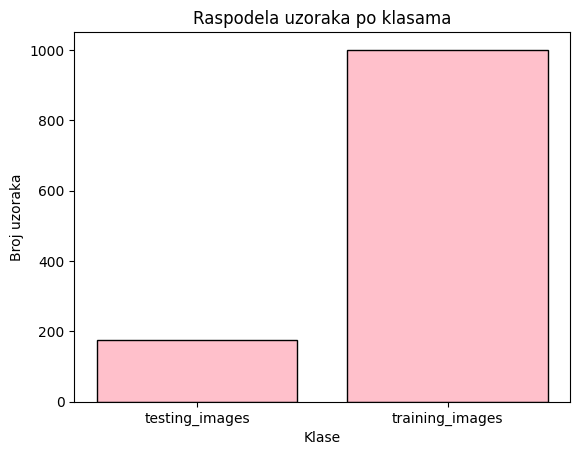

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

data_folder = "/content/dataset/data"

class_counts = {}
formats = []
dimensions = []

for cls in os.listdir(data_folder):
    cls_path = os.path.join(data_folder, cls)
    if os.path.isdir(cls_path):
        images = os.listdir(cls_path)
        class_counts[cls] = len(images)

        for img_file in images[:50]:
            img_path = os.path.join(cls_path, img_file)
            try:
                with Image.open(img_path) as img:
                    formats.append(img.format)
                    dimensions.append(img.size)
            except Exception as e:
                print(f"Greška pri otvaranju slike {img_file}: {e}")



print(f"Format slika : {set(formats)}")
print(f"Primer dimenzija slika: {dimensions[:50]}")
print(f"Broj različitih dimenzija: {len(set(dimensions))}")

plt.bar(class_counts.keys(), class_counts.values(), color="pink", edgecolor="black")
plt.title("Raspodela uzoraka po klasama")
plt.xlabel("Klase")
plt.ylabel("Broj uzoraka")
plt.show()

Analizom prosečne osvetljenosti slika utvrđeno je da se vrednosti kreću u rasponu od 47 do 100. Rezultati pokazuju da dataset pretežno sadrži srednje osvetljene slike, dok je manji deo tamnih, a svetlih nema. To znači da su slike snimljene u umerenim uslovima osvetljenja, ali bez ekstremno svetlih slika.


In [ ]:
import os
import numpy as np
from PIL import Image

data_folder = "/content/dataset/data/training_images"

brightness_values = []

for img_file in os.listdir(data_folder)[:500]:
    img_path = os.path.join(data_folder, img_file)
    try:
        with Image.open(img_path).convert("L") as img:
            arr = np.array(img)
            brightness_values.append(arr.mean())
    except:
        pass

dark = sum(b < 70 for b in brightness_values)
medium = sum(70 <= b < 140 for b in brightness_values)
bright = sum(b >= 140 for b in brightness_values)


print("Ukupan broj analiziranih slika:", len(brightness_values))
print("Tamne slike:", dark)
print("Srednje osvetljene slike:", medium)
print("Svetle slike:", bright)

print("Min osvetljenost:", min(brightness_values))
print("Max osvetljenost:", max(brightness_values))

Ukupan broj analiziranih slika: 500
Tamne slike: 117
Srednje osvetljene slike: 383
Svetle slike: 0
Min svetlina: 47.652059327312365
Max svetlina: 100.81124649641856


Analizom csv fajla utvrđeno je da dataset sadrži 559 bounding box-ova raspoređenih na 355 slika. To znači da 355 slika ima označene automobile, dok preostale slike u trening skupu nemaju anotacije i predstavljaju negativne primere (bez automobila).
Brojanjem jedinstvenih imena u koloni image dobijen je broj slika koje imaju barem jednu anotaciju.
Analizom učestalosti pojavljivanja istih imena slika utvrđeno je koje slike sadrže više objekata.
Dobijeni rezultati
Ukupan broj anotacija: 559
Broj slika koje imaju anotaciju: 355
Broj slika sa više objekata: 119


In [ ]:
import pandas as pd

csv_path = "/content/dataset/data/train_solution_bounding_boxes (1).csv"
df = pd.read_csv(csv_path)

print("Ukupan broj anotacija:", len(df))

unique_images = df["image"].nunique()
print("Broj slika koje imaju anotaciju:", unique_images)

duplicates = df["image"].value_counts()
multi_objects = duplicates[duplicates > 1]
print("\nSlike sa više objekata :")
print(multi_objects)

Ukupan broj anotacija: 559
Broj slika koje imaju anotaciju: 355

Slike sa više objekata :
image
vid_4_26460.jpg    7
vid_4_6240.jpg     6
vid_4_26400.jpg    5
vid_4_6280.jpg     5
vid_4_6260.jpg     5
                  ..
vid_4_12360.jpg    2
vid_4_12240.jpg    2
vid_4_700.jpg      2
vid_4_720.jpg      2
vid_4_13660.jpg    2
Name: count, Length: 119, dtype: int64


**Pretprocesiranje i vizualizacija**

Kako bi se obezbedila ujednačenost i kvalitet ulaznih podataka za treniranje modela, sprovedene su osnovne transformacije nad slikama:
- Normalizacija podataka

  Normalizacija je osnovni korak pretprocesiranja u kojem se vrednosti piksela slike svode na standardizovan raspon. Originalne vrednosti piksela su u rasponu od 0 do 255, a normalizacijom se skaliraju na vrednosti između 0 i 1
- Resize

  Resize je proces kojim se sve slike u dataset-u svode na istu dimenziju. Originalne slike često imaju različite rezolucije i veličine, što može predstavljati problem prilikom treniranja modela. Neuronske mreže zahtevaju da ulazne slike budu jednake dimenzije, pa je resize obavezni korak pretprocesiranja.

- Grayscale

  Iako neuronske mreže konture i ivice objekata dominantno uče kroz promene intenziteta svetlosti (što je vidljivo i u crno-belom formatu), konverzija u grayscale nije primenjena. Glavni razlog je taj što velika većina savremenih arhitektura za detekciju (kao što su YOLO, SSD ili Faster R-CNN) i njihovih pre-treniranih modela očekuje ulaz sa tri kanala (RGB). Pored toga, zadržavanje boje čuva dodatne karakteristike koje mreži olakšavaju izdvajanje automobila od pozadine u složenijim scenama.
  
- Augmentacija podataka
  
  Primenjuje se samo nad trening skupom. Povećava raznovrsnost podataka i poboljšava generalizaciju modela.
Validacioni skup se ne augmentuje, već se samo resize-uje i normalizuje.
Validacija mora da odražava realne podatke, bez dodatnih transformacija, kako bi se dobila objektivna procena performansi modela.







In [ ]:
import os
import cv2
import numpy as np
import pandas as pd

data_folder = "/content/dataset/data/training_images"
csv_path = "/content/dataset/data/train_solution_bounding_boxes (1).csv"
IMG_SIZE = (224, 224)

# Učitavanje CSV-a da znamo koje slike imaju auto
df = pd.read_csv(csv_path)
images_with_car = set(df["image"].unique())

X_data = []
y_labels = []

print("Započinjem pretprocesiranje (Resize i Normalizacija)...")
for img_file in os.listdir(data_folder):
    img_path = os.path.join(data_folder, img_file)
    img = cv2.imread(img_path)
    if img is None: continue

    # Forsiranje RGB formata
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 1. Resize
    img_resized = cv2.resize(img, IMG_SIZE)

    # 2. Normalizacija
    img_normalized = img_resized.astype(np.float32) / 255.0

    X_data.append(img_normalized)

    # Labeliranje: 1 ako je u CSV-u (ima auto), 0 ako nije (nema auto)
    if img_file in images_with_car:
        y_labels.append(1)
    else:
        y_labels.append(0)

X = np.array(X_data)
y = np.array(y_labels)
print(f"Pretprocesiranje završeno. Ukupno slika: {X.shape[0]}.")

Započinjem pretprocesiranje (Resize i Normalizacija)...
Pretprocesiranje završeno. Ukupno slika: 1001.


**Vizuelizacija podataka**

Analizom skupa podataka utvrđena je raspodela klasa na slike koje sadrže automobil (Klasa 1) i slike bez automobila (Klasa 0). Prikaz raspodele klasa realizovan je pomoću Bar chart grafika kako bi se utvrdio stepen balansiranosti skupa. Takođe, vizualizovano je nekoliko nasumičnih uzoraka iz obe klase nakon pretprocesiranja kako bi se potvrdio integritet podataka pre ulaska u model.

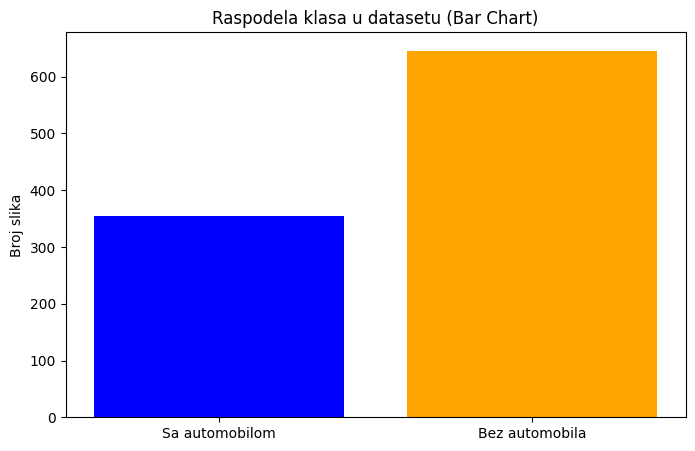

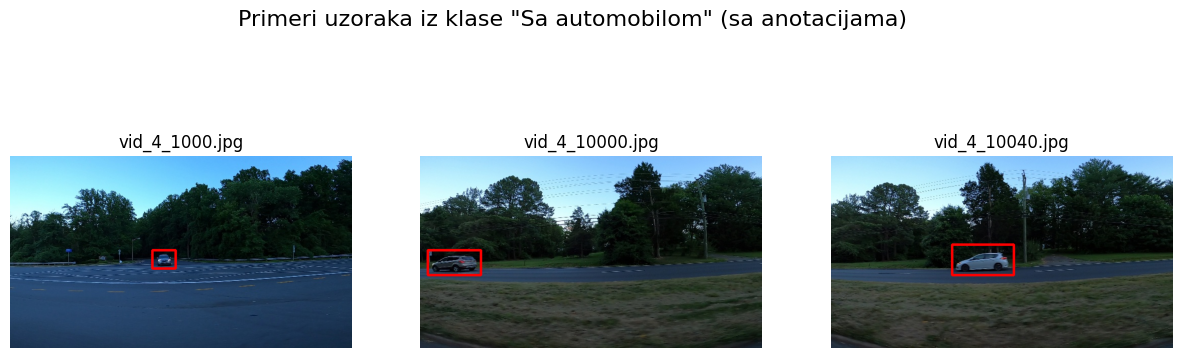

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2

data_folder = "/content/dataset/data/training_images"
csv_path = "/content/dataset/data/train_solution_bounding_boxes (1).csv"

# 1. Vizualizacija raspodele klasa (Bar chart)
df = pd.read_csv(csv_path)
slike_sa_autom = df['image'].nunique()
sve_slike = len([name for name in os.listdir(data_folder) if os.path.isfile(os.path.join(data_folder, name))])
slike_bez_auta = sve_slike - slike_sa_autom

klase = ['Sa automobilom', 'Bez automobila']
brojnosti = [slike_sa_autom, slike_bez_auta]

plt.figure(figsize=(8, 5))
plt.bar(klase, brojnosti, color=['blue', 'orange'])
plt.title('Raspodela klasa u datasetu (Bar Chart)')
plt.ylabel('Broj slika')
plt.show()

# 2. Prikaz nekoliko primera iz klase (Vizualizacija bounding box-ova)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Primeri uzoraka iz klase "Sa automobilom" (sa anotacijama)', fontsize=16)

sample_images = df['image'].unique()[:3] # Uzimamo prve tri slike
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(data_folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Izvlačimo koordinate za tu sliku
    row = df[df['image'] == img_name].iloc[0]
    cv2.rectangle(img, (int(row['xmin']), int(row['ymin'])), (int(row['xmax']), int(row['ymax'])), (255, 0, 0), 3)

    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(img_name)
plt.show()

**Podela skupa podataka**

Celokupan skup podataka podeljen je na trening (80%) i validacioni skup (20%). Ova podela je neophodna kako bi model učio šablone na jednom delu slika, dok se njegova sposobnost generalizacije i preciznog lociranja automobila na potpuno novim, neviđenim slikama objektivno testira na validacionom skupu.



In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Pre augmentacije -> Treniranje: {X_train.shape[0]}, Validacija: {X_val.shape[0]}")

Pre augmentacije -> Treniranje: 284, Validacija: 71


Kako bi se povećala raznovrsnost podataka i sprečilo preprilagođavanje modela, primenjena je augmentacija u obliku horizontalnog okretanja slika (Horizontal Flip). Vrlo je važno napomenuti da se ovaj korak izvodi isključivo nad trening skupom. Validacioni skup mora ostati netaknut kako bi predstavljao objektivnu meru performansi. Prilikom okretanja slika u ogledalu, matematički su preračunate i X koordinate okvira (bounding box-a) kako bi on ostao precizno vezan za automobil.

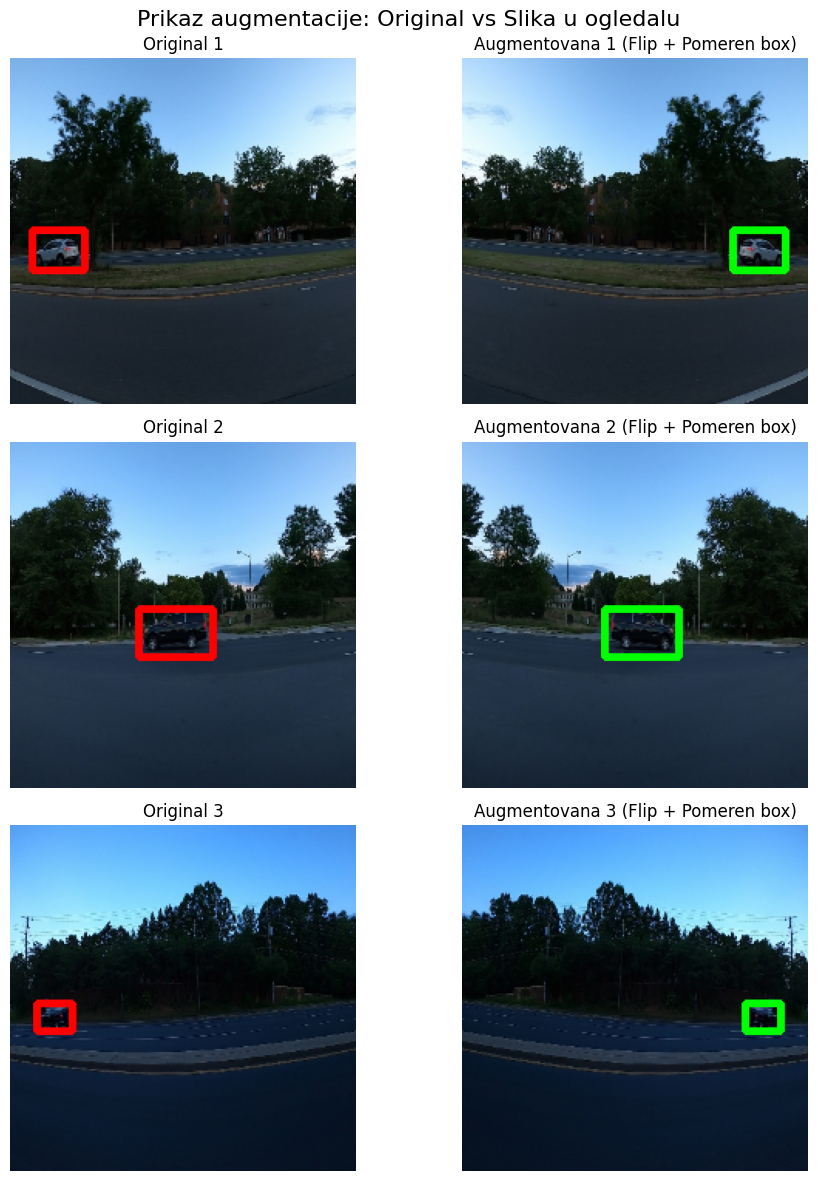

In [ ]:
import matplotlib.pyplot as plt
import cv2

# --- VIZUALIZACIJA AUGMENTACIJE (Original vs Horizontal Flip) ---
broj_primera = 3

fig, axes = plt.subplots(broj_primera, 2, figsize=(10, 4 * broj_primera))
fig.suptitle('Prikaz augmentacije: Original vs Slika u ogledalu', fontsize=16)

for i in range(broj_primera):
    # 1. Originalna slika i njene koordinate
    orig_img = X_train[i].copy()
    orig_box = y_train[i]

    # 2. Augmentovana slika i njene koordinate
    # (Nalaze se na istom indeksu i u našim privremenim aug_ listama)
    aug_img = aug_images[i].copy()
    aug_box = aug_boxes[i]

    # Slike su normalizovane (0-1), vraćamo ih u 0-255 da bi OpenCV mogao da crta
    orig_to_draw = (orig_img * 255).astype(np.uint8)
    aug_to_draw = (aug_img * 255).astype(np.uint8)

    # Crtanje pravougaonika na originalu (Crvena boja)
    cv2.rectangle(orig_to_draw, (int(orig_box[0]), int(orig_box[1])),
                  (int(orig_box[2]), int(orig_box[3])), (255, 0, 0), 3)

    # Crtanje pravougaonika na augmentovanoj slici (Zelena boja)
    cv2.rectangle(aug_to_draw, (int(aug_box[0]), int(aug_box[1])),
                  (int(aug_box[2]), int(aug_box[3])), (0, 255, 0), 3)

    # Prikaz na grafiku
    axes[i, 0].imshow(orig_to_draw)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(aug_to_draw)
    axes[i, 1].set_title(f'Augmentovana {i+1} (Flip + Pomeren box)')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

**Arhitektura Baseline modela (CNN za regresiju)**

Kreirana je jednostavna konvolutivna neuronska mreža. Model se sastoji od konvolutivnih slojeva za prepoznavanje vizuelnih obrazaca (ivica, oblika) i MaxPooling slojeva za redukciju dimenzija. S obzirom na to da je problem definisan kao binarna klasifikacija, na izlazu se nalazi jedan neuron sa sigmoid aktivacijom koji daje verovatnoću prisustva automobila (0 do 1). Model je kompajliran pomoću Adam optimizatora, dok se za merenje greške koristi Binary Crossentropy.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Definisanje arhitekture modela
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Izlazni sloj za binarnu klasifikaciju (1 neuron, sigmoid aktivacija)
    layers.Dense(1, activation='sigmoid')
])

# Kompajliranje modela
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,963,457 (45.64 MB)

 Trainable params: 11,963,457 (45.64 MB)

 Non-trainable params: 0 (0.00 B)

Proces treniranja

Model je treniran kroz 15 epoha nad augmentovanim trening skupom. Tokom svake epohe, performanse modela (gubitak i tačnost) su se paralelno pratile i nad validacionim skupom, kako bi se osiguralo da model ne krene da preprilagođava (overfit) podatke.

In [ ]:
# 2. Treniranje modela
print("\nZapočinjem treniranje baseline modela...")

history = model.fit(
    X_train_final, y_train_final,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)


Započinjem treniranje baseline modela...
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.5847 - loss: 1.8792 - val_accuracy: 0.6667 - val_loss: 0.6186
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6676 - loss: 0.6104 - val_accuracy: 0.7811 - val_loss: 0.4711
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8438 - loss: 0.3803 - val_accuracy: 0.8209 - val_loss: 0.3314
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9415 - loss: 0.1850 - val_accuracy: 0.8458 - val_loss: 0.4038
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.9812 - loss: 0.0796 - val_accuracy: 0.8507 - val_loss: 0.3884
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9978 - loss: 0.0238 - val_accuracy: 0.9005 - val_loss: 0.3131
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 0.9055 - val_loss: 0.3301
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 1.0000

Testiranje i Evaluacija

Nakon završenog treniranja, izvršena je evaluacija modela nad validacionim skupom. Model izbacuje verovatnoću prisustva objekta, pri čemu je definisan standardni prag (0.5) za klasifikaciju: sve predikcije preko 0.5 tretiraju se kao Klasa 1 (Ima auto). Na osnovu ovih predikcija izračunate su osnovne metrike: Accuracy (Ukupna tačnost) i F1-score (Harmonijska sredina preciznosti i odziva).

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 3. Generisanje predikcija nad validacionim skupom
y_pred_prob = model.predict(X_val)

# Pretvaranje verovatnoća u klase (0 ili 1) pomoću praga od 0.5
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Računanje metrika
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"\n--- REZULTATI EVALUACIJE ---")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step

--- REZULTATI EVALUACIJE ---
Accuracy: 0.9005
F1 Score: 0.8462

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       134
           1       0.87      0.82      0.85        67

    accuracy                           0.90       201
   macro avg       0.89      0.88      0.89       201
weighted avg       0.90      0.90      0.90       201



Vizualizacija Matrice konfuzije

Kako bi se stekao detaljniji uvid u to gde model greši, iscrtana je Matrica konfuzije. Ovaj grafički prikaz omogućava jasno sagledavanje odnosa između tačno prepoznatih automobila (True Positives), tačno prepoznatih praznih ulica (True Negatives), kao i lažnih detekcija i promašaja (False Positives, False Negatives).

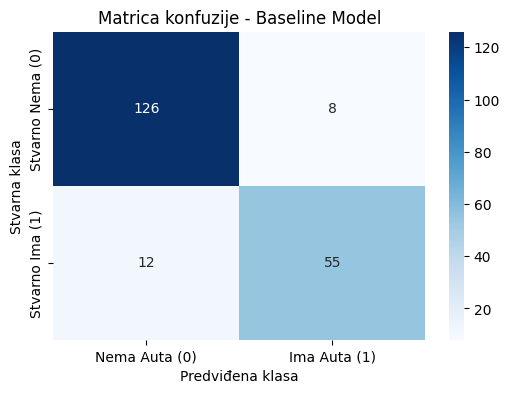

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Računanje i crtanje Matrice konfuzije
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Nema Auta (0)', 'Ima Auta (1)'],
            yticklabels=['Stvarno Nema (0)', 'Stvarno Ima (1)'])
plt.title('Matrica konfuzije - Baseline Model')
plt.ylabel('Stvarna klasa')
plt.xlabel('Predviđena klasa')
plt.show()

**Diskusija**

Analizom matrice konfuzije baseline modela može se zaključiti da model pokazuje visoku sposobnost prepoznavanja slika bez objekata (126 tačnih predikcija), dok je kod detekcije prisustva automobila postignut solidan rezultat od 55 tačnih pogodaka.

Postoji 12 promašaja gde model nije prepoznao automobil. Ovo se verovatno dešava kod uzoraka gde su automobili u senci, lošijeg kvaliteta ili neobičnih boja.

S obzirom na to da je ovo jednostavan CNN, rezultati su zadovoljavajući za baseline. U narednoj fazi, uvođenjem kompleksnijih arhitektura i finim podešavanjem, fokus će biti na smanjenju broja promašaja.